# Satellite Image — Auto Ship Detector & Cropper
Detects ships **automatically** using computer vision (OpenCV).
Works with any image from the validation dataset without manual coordinates.

| Cell | Description |
|---|---|
| 1 | Imports |
| 2 | Load image |
| 3 | Helper functions |
| 4 | Run auto-detection |
| 5 | Visualize results |
| 6 | Interactive fine-tuning |
| 7 | Crop and save ships |
| 8 | Resize to 80×80 for ML |

## 1 — Imports

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox
import os, glob

print('Imports OK')

Imports OK


## 2 — Load image
Change `INDEX` to select a different image from the validation folder.

Images found: 512

Loaded : 20181030_023205_1018_3B_Visual_9_png_jpg.rf.258385542b9b19a618f4379e57caa472.jpg
Size   : 640 × 640 px


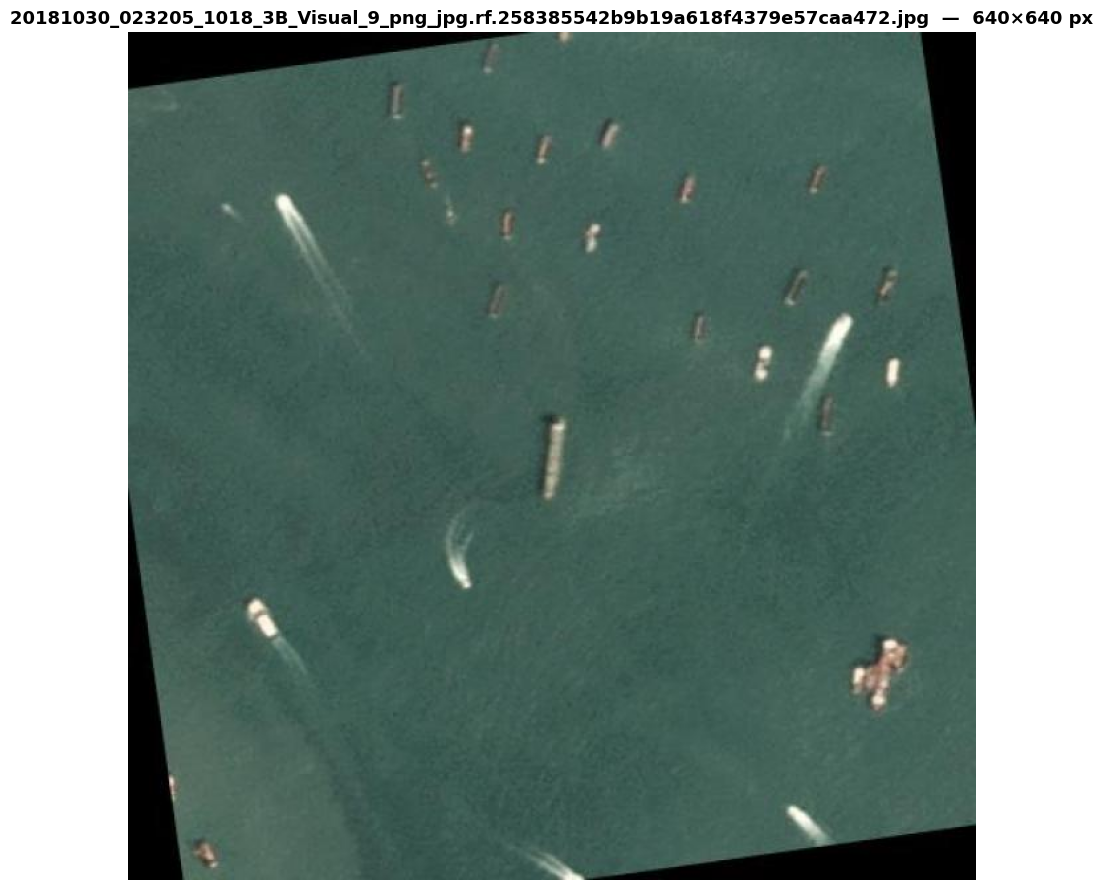

In [43]:
INDEX = 78

FOLDER = 'datasets/roboflow_annotated/valid/images'
available_images = sorted(
    glob.glob(f'{FOLDER}/**/*.png',  recursive=True) +
    glob.glob(f'{FOLDER}/**/*.jpg',  recursive=True) +
    glob.glob(f'{FOLDER}/**/*.jpeg', recursive=True)
)

if not available_images:
    raise FileNotFoundError(f'No images found in {FOLDER}.')

print(f'Images found: {len(available_images)}\n')

image_path   = available_images[INDEX]
IMG_NAME     = os.path.basename(image_path)
img_pil      = Image.open(image_path).convert('RGB')
IMG_W, IMG_H = img_pil.size
img_np       = np.array(img_pil)   # (H, W, 3) uint8 RGB

print(f'Loaded : {IMG_NAME}')
print(f'Size   : {IMG_W} × {IMG_H} px')

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(img_np)
ax.set_title(f'{IMG_NAME}  —  {IMG_W}×{IMG_H} px', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3 — Helper functions

### Detection strategy (multi-channel)
1. **V channel** (HSV brightness) → detects objects brighter than the water background
2. **Saturation channel** → detects coloured ships (red / orange / white)
3. Morphological operations to remove noise and close gaps
4. **Area** and **aspect ratio** filter → ships are elongated objects

> Parameters are auto-selected by `auto_params()` based on mean image brightness.

In [44]:
COLORS = ['#FF4444', '#44FF88', '#4488FF', '#FFAA00', '#FF44FF',
          '#00FFFF', '#FF8800', '#88FF00', '#FF0088', '#00FF88',
          '#8800FF', '#FFFF00', '#00FFFF', '#FF4444', '#44FF88', '#4488FF']


def detect_ships(
    img_rgb,
    brightness_pct = 90,
    min_area       = 60,
    max_area       = 4000,
    min_aspect     = 1.8,
    max_aspect     = 18.0,
    use_sat        = True,
    kernel_size    = 2,
):
    """
    Detect ships in an RGB satellite image.

    Returns
    -------
    ships : list of dicts — each has 'id', 'label', 'bbox'=(x,y,w,h), 'area', 'aspect'
    mask  : uint8 ndarray — binary detection mask
    """
    img_bgr  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    hsv      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v        = hsv[:, :, 2]
    s        = hsv[:, :, 1]

    thresh_v = np.percentile(v, brightness_pct)
    mask_v   = (v > thresh_v).astype(np.uint8) * 255

    if use_sat:
        thresh_s = np.percentile(s, 92)
        mask_s   = (s > thresh_s).astype(np.uint8) * 255
        mask     = cv2.bitwise_or(mask_v, mask_s)
    else:
        mask = mask_v

    k    = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    ships = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if not (min_area <= area <= max_area):
            continue

        x, y, w, h = cv2.boundingRect(contour)
        long_side  = max(w, h)
        short_side = max(min(w, h), 1)   # guard against zero-width contours
        aspect     = long_side / short_side

        if not (min_aspect <= aspect <= max_aspect):
            continue
        if long_side < 8:
            continue

        ships.append({
            'bbox'  : (x, y, w, h),
            'area'  : round(area, 1),
            'aspect': round(aspect, 2),
        })

    ships.sort(key=lambda ship: -ship['area'])
    for i, ship in enumerate(ships):
        ship['id']    = i + 1
        ship['label'] = f'Ship {i + 1}'

    return ships, mask


def auto_params(img_rgb):
    """Select detection parameters based on mean image brightness."""
    mean_brightness = np.mean(img_rgb)

    if mean_brightness < 80:       # deep blue water
        return dict(brightness_pct=88, min_area=50, max_area=5000,
                    min_aspect=1.8, max_aspect=18, use_sat=True,  kernel_size=2)
    elif mean_brightness < 140:    # teal background, possible clouds
        return dict(brightness_pct=93, min_area=80, max_area=2000,
                    min_aspect=2.0, max_aspect=14, use_sat=False, kernel_size=2)
    else:                          # bright / high reflectance
        return dict(brightness_pct=95, min_area=60, max_area=3000,
                    min_aspect=1.8, max_aspect=16, use_sat=False, kernel_size=3)


def crop_ship(img_pil, bbox, padding=12):
    """Crop a single ship from a PIL image with optional padding."""
    x, y, w, h = bbox
    iw, ih = img_pil.size
    x1 = max(0,  x - padding)
    y1 = max(0,  y - padding)
    x2 = min(iw, x + w + padding)
    y2 = min(ih, y + h + padding)
    return img_pil.crop((x1, y1, x2, y2))


print('Helper functions defined.')

Helper functions defined.


## 4 — Run auto-detection
Parameters are selected automatically from `auto_params()`. Re-run after changing the image in Cell 2.

In [45]:
params = auto_params(img_np)
print(f'Mean image brightness : {np.mean(img_np):.1f}')
print(f'Auto-selected params  : {params}\n')

SHIPS, MASK = detect_ships(img_np, **params)

print(f'Ships detected: {len(SHIPS)}')
for ship in SHIPS:
    x, y, w, h = ship['bbox']
    print(f"  {ship['label']:10s}  bbox=({x:4d},{y:4d},{w:3d},{h:3d})  "
          f"area={ship['area']:7.0f}px²  aspect={ship['aspect']:.2f}")

Mean image brightness : 79.4
Auto-selected params  : {'brightness_pct': 88, 'min_area': 50, 'max_area': 5000, 'min_aspect': 1.8, 'max_aspect': 18, 'use_sat': True, 'kernel_size': 2}

Ships detected: 27
  Ship 1      bbox=( 327,   0,184, 55)  area=   3333px²  aspect=3.35
  Ship 2      bbox=( 365, 571,235, 69)  area=   2522px²  aspect=3.41
  Ship 3      bbox=( 564,   0, 76,272)  area=   2500px²  aspect=3.58
  Ship 4      bbox=( 193,   0, 97, 18)  area=    762px²  aspect=5.39
  Ship 5      bbox=( 240, 362, 23, 62)  area=    682px²  aspect=2.70
  Ship 6      bbox=( 316, 292, 18, 64)  area=    594px²  aspect=3.56
  Ship 7      bbox=(  81,  17,110, 16)  area=    578px²  aspect=6.88
  Ship 8      bbox=( 381, 462, 51, 27)  area=    502px²  aspect=1.89
  Ship 9      bbox=( 302, 617, 72, 23)  area=    446px²  aspect=3.13
  Ship 10     bbox=(   0, 348, 10, 55)  area=    262px²  aspect=5.50
  Ship 11     bbox=( 573, 248, 15, 29)  area=    246px²  aspect=1.93
  Ship 12     bbox=( 602, 597, 38, 14) 

## 5 — Visualize results
Image with bounding boxes on the left, binary detection mask on the right.

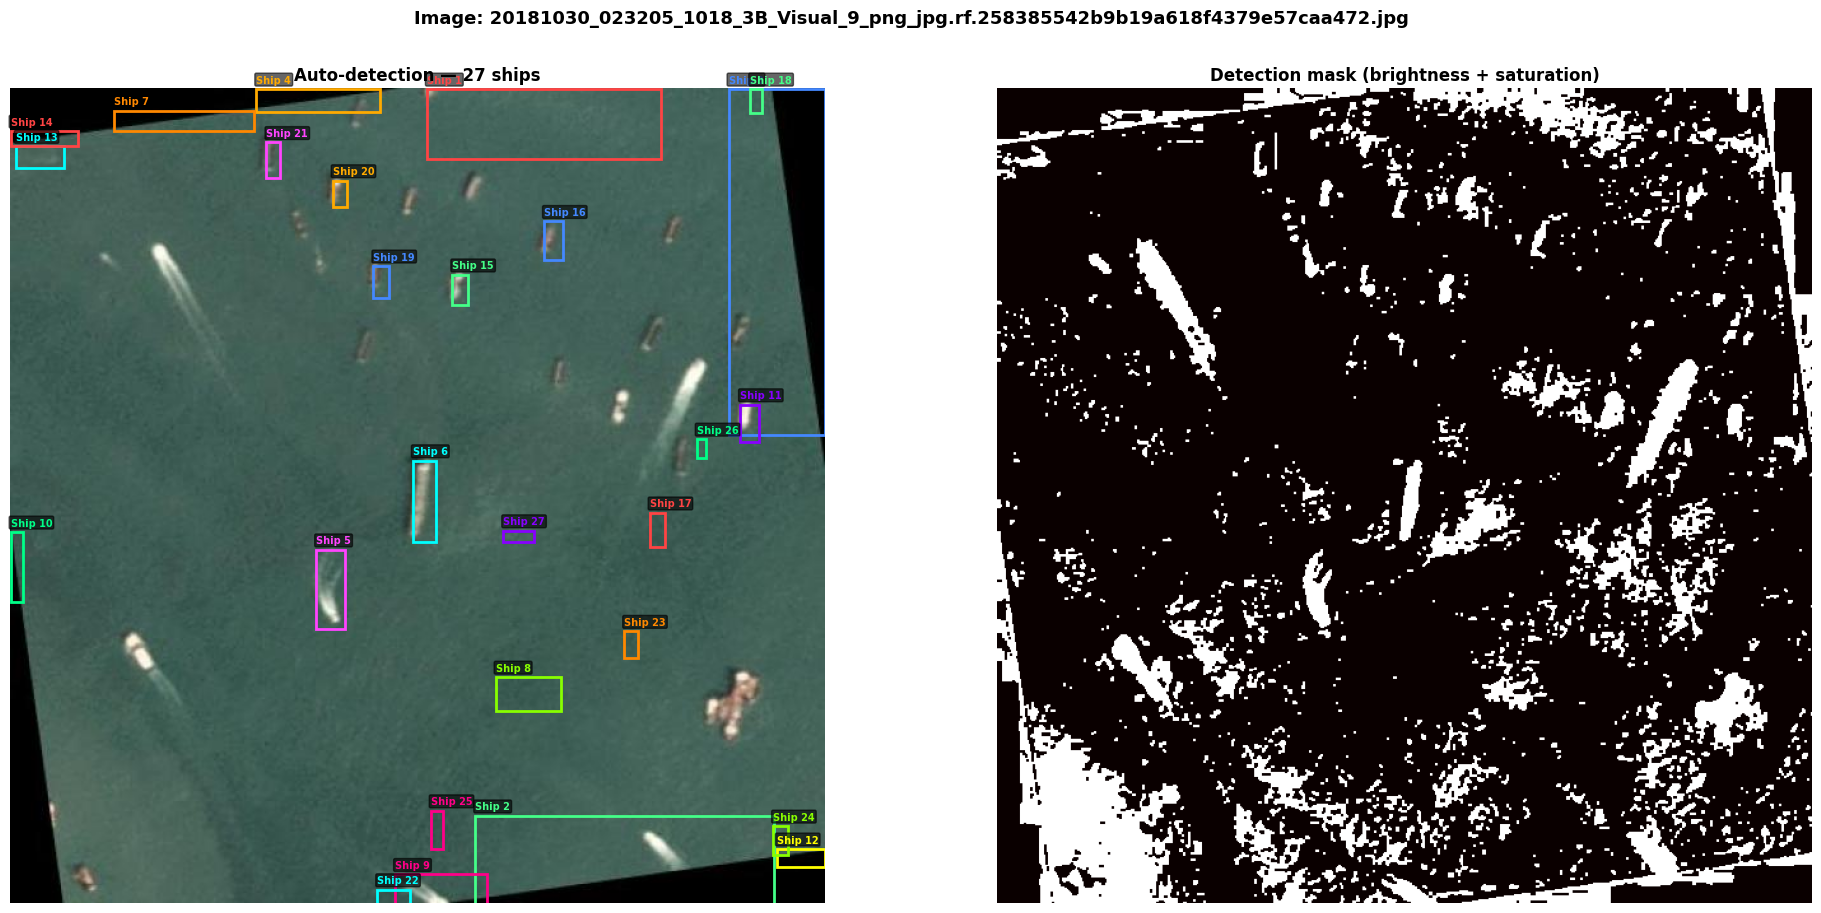

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].imshow(img_np)
for i, ship in enumerate(SHIPS):
    x, y, w, h = ship['bbox']
    color = COLORS[i % len(COLORS)]
    rect  = patches.Rectangle((x, y), w, h,
                                linewidth=2, edgecolor=color, facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x, y - 5, ship['label'], color=color, fontsize=7,
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))
axes[0].set_title(f'Auto-detection — {len(SHIPS)} ships', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(MASK, cmap='hot')
axes[1].set_title('Detection mask (brightness + saturation)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle(f'Image: {IMG_NAME}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6 — Interactive fine-tuning

Move the sliders to refine detection parameters. Results update live.
After finding good parameters, re-run **Cell 7** to save the crops.

> **Local Jupyter compatibility:** `interact` works in both **classic Jupyter Notebook** and **JupyterLab ≥ 3.0** once `ipywidgets` is installed. JupyterLab < 3.0 also needs `jupyter labextension install @jupyter-widgets/jupyterlab-manager`. In **VS Code**, the Jupyter extension must be active and connected to a running kernel — the plain Python Interactive panel does not render widgets.

In [ ]:
def update_detection(brightness_pct, min_area, max_area, min_aspect, max_aspect, use_sat):
    global SHIPS, MASK   # updated so Cell 8 (crop) uses the latest detection

    SHIPS, MASK = detect_ships(
        img_np,
        brightness_pct = brightness_pct,
        min_area       = min_area,
        max_area       = max_area,
        min_aspect     = min_aspect,
        max_aspect     = max_aspect,
        use_sat        = use_sat,
    )

    plt.close('all')   # prevent figure accumulation on repeated slider moves
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    axes[0].imshow(img_np)
    for i, ship in enumerate(SHIPS):
        x, y, w, h = ship['bbox']
        color = COLORS[i % len(COLORS)]
        rect  = patches.Rectangle((x, y), w, h,
                                    linewidth=2, edgecolor=color, facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x, y - 5, ship['label'], color=color, fontsize=7,
                     fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))
    axes[0].set_title(f'{len(SHIPS)} ships detected', fontsize=11, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(MASK, cmap='hot')
    axes[1].set_title('Binary mask', fontsize=11, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Ships found: {len(SHIPS)}')


interact(
    update_detection,
    brightness_pct = IntSlider(  value=params['brightness_pct'], min=70,  max=99,    step=1,   description='Brightness %'),
    min_area       = IntSlider(  value=params['min_area'],        min=10,  max=500,   step=10,  description='Area min'),
    max_area       = IntSlider(  value=params['max_area'],        min=200, max=15000, step=100, description='Area max'),
    min_aspect     = FloatSlider(value=params['min_aspect'],      min=1.0, max=5.0,   step=0.1, description='Aspect min'),
    max_aspect     = FloatSlider(value=params['max_aspect'],      min=5.0, max=30.0,  step=0.5, description='Aspect max'),
    use_sat        = Checkbox(   value=params['use_sat'],                             description='Use saturation'),
);

interactive(children=(IntSlider(value=88, description='Brightness %', max=99, min=70), IntSlider(value=50, des…

## 7 — Crop and save ships
Crops are saved to the `crops/` folder. Re-run this cell after adjusting detection in Cell 6.

  Saved: crops/ship_01.png  (124x284 px)
  Saved: crops/ship_02.png  (48x94 px)
  Saved: crops/ship_03.png  (121x30 px)
  Saved: crops/ship_04.png  (42x89 px)
  Saved: crops/ship_05.png  (134x40 px)
  Saved: crops/ship_06.png  (75x51 px)
  Saved: crops/ship_07.png  (97x36 px)
  Saved: crops/ship_08.png  (22x79 px)
  Saved: crops/ship_09.png  (50x38 px)
  Saved: crops/ship_10.png  (46x65 px)
  Saved: crops/ship_11.png  (36x48 px)
  Saved: crops/ship_12.png  (40x56 px)
  Saved: crops/ship_13.png  (43x60 px)
  Saved: crops/ship_14.png  (36x51 px)
  Saved: crops/ship_15.png  (39x51 px)
  Saved: crops/ship_16.png  (33x35 px)
  Saved: crops/ship_17.png  (35x45 px)


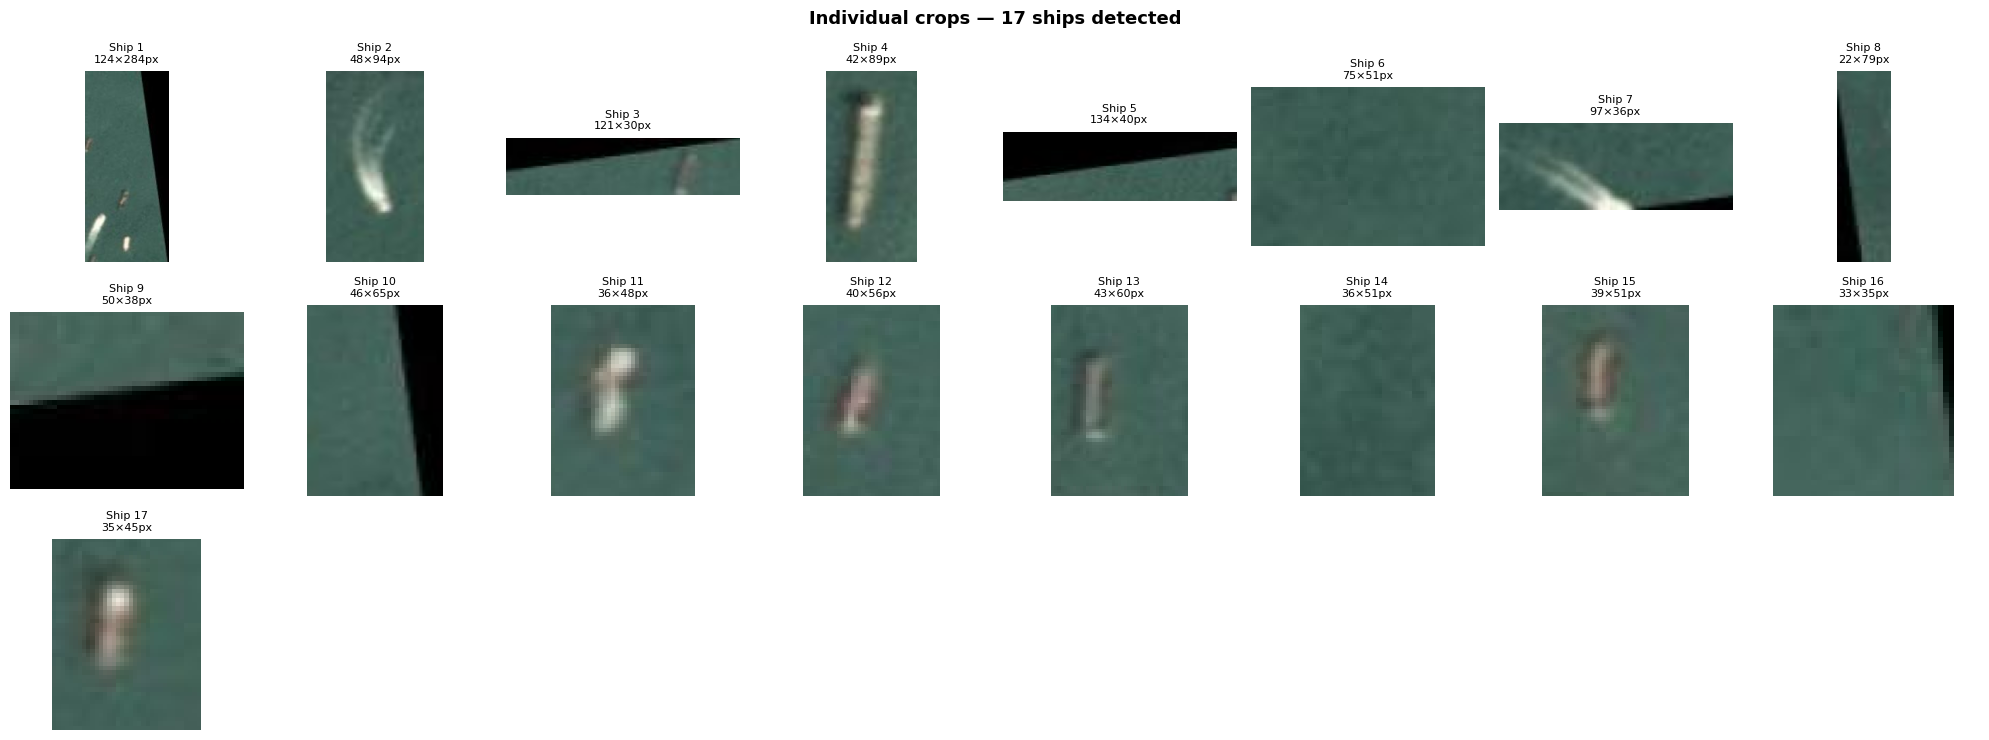

In [50]:
PADDING = 12

os.makedirs('crops', exist_ok=True)
crops = []
for ship in SHIPS:
    crop = crop_ship(img_pil, ship['bbox'], padding=PADDING)
    crops.append(crop)
    filename = f"crops/ship_{ship['id']:02d}.png"
    crop.save(filename)
    print(f"  Saved: {filename}  ({crop.size[0]}x{crop.size[1]} px)")

n = len(crops)
if n == 0:
    print('No ships found. Adjust parameters in Cell 7.')
else:
    cols = min(n, 8)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.array(axes).flatten()

    for i, (ship, crop) in enumerate(zip(SHIPS, crops)):
        axes[i].imshow(np.array(crop))
        axes[i].set_title(f"{ship['label']}\n{crop.size[0]}×{crop.size[1]}px", fontsize=8)
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Individual crops — {n} ships detected', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8 — Resize to 80×80 for ML
Saves `ship_XX_80x80.png` alongside the original crops. Change `TARGET_SIZE` if another resolution is needed.

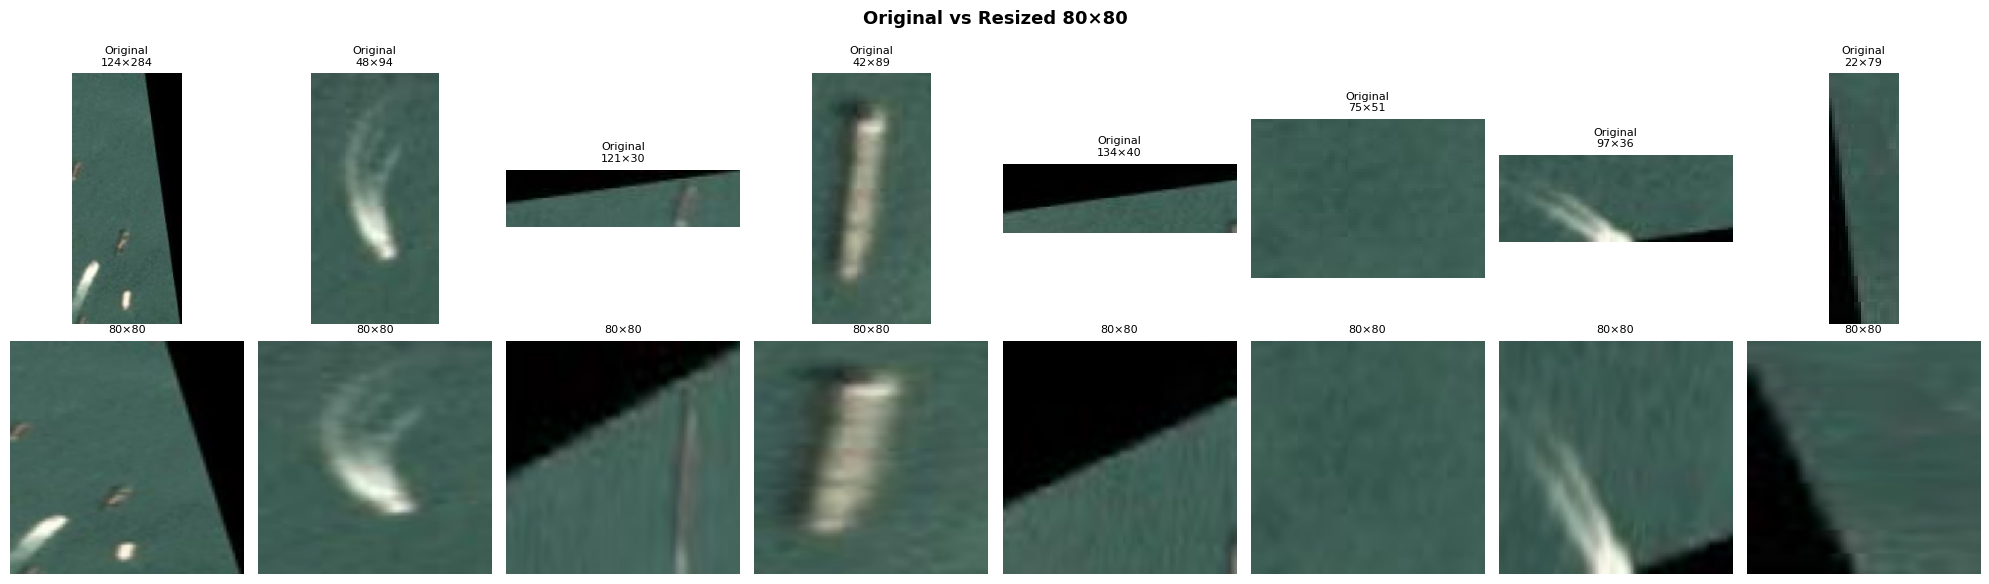


Array ready for TensorFlow / Keras:
  shape = (17, 80, 80, 3)  →  (N_ships, height, width, channels)
  dtype = uint8


In [51]:
TARGET_SIZE = (80, 80)

crops_resized = []
for ship, crop in zip(SHIPS, crops):
    resized = crop.resize(TARGET_SIZE, Image.LANCZOS)
    crops_resized.append(np.array(resized))
    resized.save(f"crops/ship_{ship['id']:02d}_80x80.png")

n    = len(crops)
cols = min(n, 8)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(2, cols, figsize=(cols * 2.5, 6))
if cols == 1:
    axes = axes.reshape(2, 1)

for i in range(cols):
    if i < n:
        axes[0, i].imshow(np.array(crops[i]))
        axes[0, i].set_title(f'Original\n{crops[i].size[0]}×{crops[i].size[1]}', fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(crops_resized[i])
        axes[1, i].set_title('80×80', fontsize=8)
        axes[1, i].axis('off')
    else:
        axes[0, i].axis('off')
        axes[1, i].axis('off')

plt.suptitle('Original vs Resized 80×80', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

batch = np.array(crops_resized)
print(f'\nArray ready for TensorFlow / Keras:')
print(f'  shape = {batch.shape}  →  (N_ships, height, width, channels)')
print(f'  dtype = {batch.dtype}')